# Model Trainer

## Imports

In [17]:
import os
import re

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"  # 1
os.environ[
    "XLA_FLAGS"
] = "--xla_gpu_cuda_data_dir=/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/"

import tensorflow as tf

keras = tf.keras  # fixes issues with vsCode
from keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 13})

from functools import partial

from keras import Input, Model
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import (
    Layer,
    LeakyReLU,
    Add,
    UpSampling2D,
    Activation,
    SpatialDropout2D,
    Conv2D,
    BatchNormalization,
    Concatenate,
    Flatten,
    Dense,
    RandomRotation,
    RandomFlip,
    RandomZoom,
)
from keras.optimizers import Adam
from tensorflow_addons.layers import InstanceNormalization

from IPython.display import clear_output
from datetime import datetime

from tensorflow import pad

from keras.callbacks import (
    LambdaCallback,
    TensorBoard,
    EarlyStopping,
    ModelCheckpoint,
    LearningRateScheduler,
)

%matplotlib inline

# tf.debugging.set_log_device_placement(False)

print(f"tf version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(gpus)
print(tf.config.experimental.get_memory_info('GPU:0'))
# tf.config.experimental.set_memory_growth(gpus[0], True)

tf version: 2.11.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{'current': 2556987392, 'peak': 2687013120}


We used MirroredStrategy to allow for multiGPU setups, can use onedevice if you need to debug things and don't want to change server settings.

You need to use `with strategy.scope():` anytime you call a tensorflow function with this code or you will get errors.

In [18]:
strategy = tf.distribute.MirroredStrategy()
# stragety = tf.distribute.OneDeviceStrategy(device="/gpu:0") # for debugging

# config = tf.ConfigProto()
# config.gpu_options.allow_growth = True

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


Lets make the folders to support our stuff. You can disable tensorboard support here if you want

In [19]:
use_tensorboard = True

# some base settings for files
model_name = "camb"
data_dir = f"data/{model_name}"
model_dir = f"data/models/{model_name}"
plot_dir = f"data/plots/{model_name}"
tb_dir = f"data/tensorboard/{model_name}"

def mk_dir(dir):
    if not os.path.exists(dir):
        print(f"Creating dir: {dir}")
        os.makedirs(dir)
    else:
        print(f'Using existing folder: {dir}')

mk_dir(data_dir)
mk_dir(model_dir)
mk_dir(plot_dir)
if use_tensorboard:
    mk_dir(tb_dir)

Using existing folder data/camb
Using existing folder data/models/camb
Using existing folder data/plots/camb
Using existing folder data/tensorboard/camb


## TensorBoard

Will launch an in-notebook tensorboard session, might need to change port.

In [20]:
%load_ext tensorboard
%tensorboard --logdir data/tensorboard/ --port 23465
print('open http://localhost:23465/')

open http://localhost:23465/


## Model Code

In [21]:
def load_data(data_dir, base_name):
    # load fnls, which are in the base dir
    fnls = np.load(f"{data_dir}/{base_name}-fnls.npy")

    # List all files in data_dir
    all_files = os.listdir(data_dir)

    # Filter files that match the base_name and specific format
    pattern = re.compile(f"{base_name}_\d+-\d+\.npy")
    filtered_files = [file for file in all_files if pattern.match(file)]

    # Sort files based on the first range value
    filtered_files.sort(key=lambda x: int(re.search("\d+", x).group()))

    print(f'loading files {filtered_files}')
    
    # Load data from files and append to a list
    data_list = []
    for file in filtered_files:
        file_path = os.path.join(data_dir, file)
        print(f'loading {file_path}')
        data = np.load(file_path)
        data_list.append(data)

    # Concatenate data into a single numpy array
    data_array = np.concatenate(data_list, axis=0)
    return data_array, fnls

### Helper Functions

In [22]:
class ReflectionPadding2D(Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        self.input_spec = [tf.keras.layers.InputSpec(ndim=4)]
        super(ReflectionPadding2D, self).__init__(**kwargs)

    def compute_output_shape(self, s):
        """If you are using "channels_last" configuration"""
        return (s[0], s[1] + 2 * self.padding[0], s[2] + 2 * self.padding[1], s[3])

    def call(self, x, mask=None):
        w_pad, h_pad = self.padding
        return pad(x, [[0, 0], [h_pad, h_pad], [w_pad, w_pad], [0, 0]], "REFLECT")


def create_localization_module(input_layer, n_filters):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(layer1, n_filters)
    return create_convolution_block(convolution1, n_filters, kernel=(1, 1))


def create_up_sampling_module(input_layer, n_filters, size=(2, 2)):
    up_sample = UpSampling2D(size=size)(input_layer)
    layer1 = ReflectionPadding2D()(up_sample)
    return create_convolution_block(layer1, n_filters)


def create_context_module(
    input_layer, n_level_filters, dropout_rate=0.1, data_format="channels_last"
):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(
        input_layer=layer1, n_filters=n_level_filters
    )
    dropout = SpatialDropout2D(rate=dropout_rate, data_format=data_format)(convolution1)
    layer2 = ReflectionPadding2D()(dropout)
    return create_convolution_block(
        input_layer=layer2, n_filters=n_level_filters
    )


def create_convolution_block(
    input_layer,
    n_filters,
    batch_normalization=False,
    kernel=(3, 3),
    activation=LeakyReLU,
    padding="valid",
    strides=(1, 1),
    instance_normalization=False,
):
    """
    :param strides:
    :param input_layer:
    :param n_filters:
    :param batch_normalization:
    :param kernel:
    :param activation: Keras activation layer to use. (default is 'relu')
    :param padding:
    :return:
    """
    layer = Conv2D(n_filters, kernel, padding=padding, strides=strides)(input_layer)
    if batch_normalization:
        layer = BatchNormalization()(layer)
    elif instance_normalization:
        layer = InstanceNormalization()(layer)
    return Activation("relu")(layer) if activation is None else activation()(layer)


def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_coefficient_loss(y_true, y_pred):
    return -dice_coefficient(y_true, y_pred)

### Model Architecture

In [23]:
with strategy.scope():
    create_convolution_block = partial(create_convolution_block, activation=LeakyReLU, instance_normalization=True)


def isensee2017_model(
    inputs,
    n_base_filters=16,
    depth=5,
    dropout_rate=0.3,
    n_segmentation_levels=3,
    n_labels=1,
    optimizer=Adam,
    initial_learning_rate=5e-4,
    loss_function=dice_coefficient_loss,
    activation_name="relu",
    name=''
):
    """
    This function builds a model proposed by Isensee et al. for the BRATS 2017 competition:
    https://www.cbica.upenn.edu/sbia/Spyridon.Bakas/MICCAI_BraTS/MICCAI_BraTS_2017_proceedings_shortPapers.pdf
    This network is highly similar to the model proposed by Kayalibay et al. "CNN-based Segmentation of Medical
    Imaging Data", 2017: https://arxiv.org/pdf/1701.03056.pdf
    :param inputs:
    :param n_base_filters:
    :param depth:
    :param dropout_rate:
    :param n_segmentation_levels:
    :param n_labels:
    :param optimizer:
    :param initial_learning_rate:
    :param loss_function:
    :param activation_name:
    :return:
    """

    current_layer = inputs
    level_output_layers = []
    level_filters = []
    # n_level_filters = (2**level_number) * n_base_filters
    n_level_filters = 8
    for _ in range(depth):
        level_filters.append(n_level_filters)

        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(
            in_conv, n_level_filters, dropout_rate=dropout_rate
        )

        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    segmentation_layers = []
    for level_number in range(depth - 2, -1, -1):
        up_sampling = create_up_sampling_module(
            current_layer, level_filters[level_number]
        )
        concatenation_layer = Concatenate()(
            [level_output_layers[level_number], up_sampling]
        )
        localization_output = create_localization_module(
            concatenation_layer, level_filters[level_number]
        )
        current_layer = localization_output
        if level_number < n_segmentation_levels:
            segmentation_layers.insert(0, Conv2D(n_labels, (1, 1))(current_layer))

    output_layer = None
    for level_number in reversed(range(n_segmentation_levels - 1)):
        segmentation_layer = segmentation_layers[level_number]
        if output_layer is None:
            output_layer = segmentation_layer
        else:
            output_layer = Add()([output_layer, segmentation_layer])

        if level_number > 0:
            output_layer = UpSampling2D(size=(2, 2))(output_layer)

    flat_layer = Flatten()(output_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer, name=name)
    model.compile(
        optimizer=optimizer(learning_rate=initial_learning_rate),
        loss=loss_function,
        metrics=tf.keras.metrics.RootMeanSquaredError(),
    )
    return model

def make_bs_model(
    inputs,
    depth=5,
    dropout_rate=0.3,
    optimizer=Adam,
    initial_learning_rate=5e-4,
    loss_function=dice_coefficient_loss,
    name="custom_model",
    preprocess=False,
):
    if preprocess:
        inputs = RandomFlip("horizontal")(inputs)
        # inputs = RandomZoom(0.2)(inputs)
        inputs = RandomRotation(np.pi)(inputs)

    current_layer = inputs
    level_output_layers = []
    level_filters = []
    n_level_filters = 16 
    for _ in range(depth):
        level_filters.append(n_level_filters)

        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(
            in_conv, n_level_filters, dropout_rate=dropout_rate
        )
        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    flat_layer = Flatten()(current_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer, name=name)
    model.compile(
        optimizer=optimizer(learning_rate=initial_learning_rate),
        loss=loss_function,
        metrics=tf.keras.metrics.RootMeanSquaredError(),
    )
    return model

## Load Data

First lets setup the config so we know what data to load, this needs to match the output of `dataGenerator`, of course.

In [24]:
# These settings should match the generation settings, from there it will just load the files correctly
img_size = 128
train_size_k = 10
train_size = train_size_k * 1000
fnl_range = [-1000, 1000]
num_dup=10

# model settins, will also be used to inform data loading
batch_size = 32
max_epochs = 100

save_models=True

basename = f"{img_size}x{train_size_k}k-{num_dup}_fnl{fnl_range[0]}-{fnl_range[1]}"
data_dir = f"{data_dir}/{basename}"
run_time = datetime.now().strftime("%Y%m%d-%H%M%S")

Lets load the data, a lot of the weird things are to make sure the data and fnls do not get scrabled. 

Might want to refactor that code to make this unnessary and to prevent issues.

In [25]:
N_train = int(train_size * 0.8)
N_val = int(train_size * 0.1)
N_test = int(train_size * 0.1)

data, fnls = load_data(data_dir, basename)
print(f'Loaded data shape: {data.shape}, fnl shape: {fnls.shape}')

# split into training and testing data
X_train = data[:N_train]
X_test = data[N_train : N_train + N_test]
X_val = data[N_train + N_test : N_train + N_test + N_val]

y_train = fnls[:N_train]
y_test = fnls[N_train : N_train + N_test]
y_val = fnls[N_train + N_test : N_train + N_test + N_val]

print(f'Train data shape: {X_train.shape}, fnls: {y_train.shape}')
print(f'Validations data shape: {X_val.shape}, fnls: {y_val.shape}')
print(f'Test data shape: {X_test.shape}, fnls: {y_test.shape}')

# Our sets are not big enought to do really complex loading into ram, but we still need to do stuff for the gpu
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE)

loading files ['128x10k-10_fnl-1000-1000_0-10000.npy']
loading data/camb/128x10k-10_fnl-1000-1000/128x10k-10_fnl-1000-1000_0-10000.npy
Loaded data shape: (10000, 128, 128), fnl shape: (10000,)
Train data shape: (8000, 128, 128), fnls: (8000,)
Validations data shape: (1000, 128, 128), fnls: (1000,)
Test data shape: (1000, 128, 128), fnls: (1000,)


### Check Data

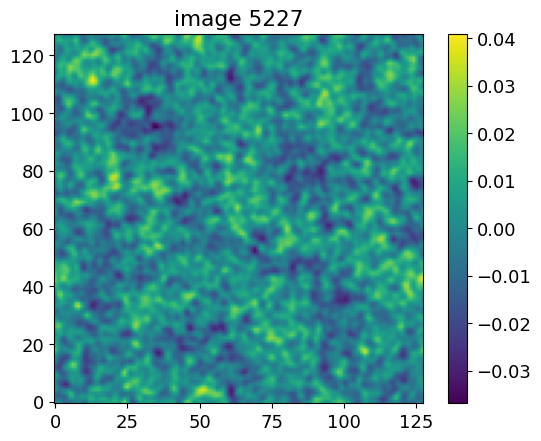

In [26]:
ri = np.random.randint(len(data))
plt.imshow(data[ri], origin="lower")
plt.title(f"image {ri}")
plt.colorbar()
plt.savefig(f"{plot_dir}/{basename}_example.png")
plt.show()

## Train Model

Set up callbacks for both models.

In [27]:
# Help keep the output clean in VS Code, might want to remove this if you're not using VS Code
def clearOutput(batch, logs):
    clear_output(wait=True)


with strategy.scope():
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-5, decay_steps=1000, decay_rate=0.9
    )

    callbacks = [
        EarlyStopping(monitor="val_root_mean_squared_error", patience=10),
        ModelCheckpoint(
            filepath=f"{model_dir}/checkpoint_{run_time}.keras",
            monitor="val_root_mean_squared_error",
            save_best_only=True,
        ),
        # LearningRateScheduler(lr_schedule),
        # LambdaCallback(on_epoch_begin=clearOutput),
    ]
    if use_tensorboard:
        logs = f"{tb_dir}/{basename}_{run_time}"
        callbacks.append(TensorBoard(log_dir=logs))

In [28]:
with strategy.scope():
    input_img = Input((img_size, img_size, 1), name="img")
    isensee_model = isensee2017_model(
        input_img,
        depth=5,
        n_segmentation_levels=3,
        dropout_rate=0.3,
        loss_function=tf.keras.losses.mse,
        initial_learning_rate=1e-3,
        name=f"{model_name}-isensee-{basename}",
    )
    # isensee_model.summary()
    
    isensee_model.fit(
        train_dataset,
        validation_data=val_dataset,
        batch_size=batch_size,
        epochs=max_epochs,
        callbacks=callbacks,
    )

    if save_models:
        modelfile = f"{model_dir}/{basename}-isensee_{run_time}"
        isensee_model.save(modelfile)

2023-05-09 12:34:26.607323: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:784] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_DOUBLE
      type: DT_FLOAT
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 8000
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\026TensorSliceDataset:551"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 128
        }
        dim {
          size: 128
        }
      }
      shape {
      }
    }
  }
}
attr {
  key: "replicate_on_split"
  value {
    b: false
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args 

Epoch 1/100


2023-05-09 12:34:39.352926: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incamb-isensee-128x10k-10_fnl-1000-1000/spatial_dropout2d_11/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


250/250 [==============================] - ETA: 0s - loss: 332151.0938 - root_mean_squared_error: 576.3255

2023-05-09 12:34:56.820581: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:784] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_DOUBLE
      type: DT_FLOAT
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1000
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\026TensorSliceDataset:555"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 128
        }
        dim {
          size: 128
        }
      }
      shape {
      }
    }
  }
}
attr {
  key: "replicate_on_split"
  value {
    b: false
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args 

250/250 [==============================] - 32s 76ms/step - loss: 332151.0938 - root_mean_squared_error: 576.3255 - val_loss: 339793.1250 - val_root_mean_squared_error: 582.9178
Epoch 2/100
250/250 [==============================] - 16s 65ms/step - loss: 329286.9688 - root_mean_squared_error: 573.8353 - val_loss: 342882.8750 - val_root_mean_squared_error: 585.5620
Epoch 3/100
250/250 [==============================] - 16s 65ms/step - loss: 319309.9062 - root_mean_squared_error: 565.0751 - val_loss: 347675.3750 - val_root_mean_squared_error: 589.6400
Epoch 4/100
250/250 [==============================] - 16s 66ms/step - loss: 309071.6875 - root_mean_squared_error: 555.9421 - val_loss: 353530.6250 - val_root_mean_squared_error: 594.5844
Epoch 5/100
250/250 [==============================] - 17s 66ms/step - loss: 302114.5625 - root_mean_squared_error: 549.6495 - val_loss: 363702.0312 - val_root_mean_squared_error: 603.0771
Epoch 6/100
250/250 [==============================] - 17s 66ms/ste

INFO:tensorflow:Assets written to: data/models/camb/128x10k-10_fnl-1000-1000-isensee_20230509-123417/assets


INFO:tensorflow:Assets written to: data/models/camb/128x10k-10_fnl-1000-1000-isensee_20230509-123417/assets


In [29]:
with strategy.scope():
    input_img = Input((img_size, img_size, 1), name="img")
    bs_model = make_bs_model(
        input_img,
        depth=6,
        dropout_rate=0.3,
        loss_function=tf.keras.losses.mse,
        initial_learning_rate=1e-3,
        preprocess=True,
        name=f"{model_name}-{basename}",
    )
    # bs_model.summary()
    
    bs_model.fit(
        train_dataset,
        validation_data=val_dataset,
        batch_size=batch_size,
        epochs=max_epochs,
        callbacks=callbacks,
    )

    if save_models:
        modelfile = f"{model_dir}/{basename}_{run_time}"
        bs_model.save(modelfile)

2023-05-09 12:38:11.729899: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:784] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_DOUBLE
      type: DT_FLOAT
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 8000
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\026TensorSliceDataset:551"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 128
        }
        dim {
          size: 128
        }
      }
      shape {
      }
    }
  }
}
attr {
  key: "replicate_on_split"
  value {
    b: false
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args 

Epoch 1/100


2023-05-09 12:38:21.517184: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incamb-128x10k-10_fnl-1000-1000/spatial_dropout2d_16/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


250/250 [==============================] - ETA: 0s - loss: 332120.8750 - root_mean_squared_error: 576.2993

2023-05-09 12:38:34.997666: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:784] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_DOUBLE
      type: DT_FLOAT
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1000
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\026TensorSliceDataset:555"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 128
        }
        dim {
          size: 128
        }
      }
      shape {
      }
    }
  }
}
attr {
  key: "replicate_on_split"
  value {
    b: false
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args 

250/250 [==============================] - 25s 62ms/step - loss: 332120.8750 - root_mean_squared_error: 576.2993 - val_loss: 340509.8750 - val_root_mean_squared_error: 583.5322
Epoch 2/100
250/250 [==============================] - 13s 52ms/step - loss: 332006.3750 - root_mean_squared_error: 576.2000 - val_loss: 340858.9688 - val_root_mean_squared_error: 583.8313
Epoch 3/100
250/250 [==============================] - 13s 52ms/step - loss: 331712.8750 - root_mean_squared_error: 575.9452 - val_loss: 340941.4375 - val_root_mean_squared_error: 583.9019
Epoch 4/100
250/250 [==============================] - 13s 51ms/step - loss: 331382.4062 - root_mean_squared_error: 575.6583 - val_loss: 341800.3750 - val_root_mean_squared_error: 584.6370
Epoch 5/100
250/250 [==============================] - 13s 51ms/step - loss: 330571.8125 - root_mean_squared_error: 574.9537 - val_loss: 341594.5938 - val_root_mean_squared_error: 584.4609
Epoch 6/100
250/250 [==============================] - 13s 52ms/ste

INFO:tensorflow:Assets written to: data/models/camb/128x10k-10_fnl-1000-1000_20230509-123417/assets


INFO:tensorflow:Assets written to: data/models/camb/128x10k-10_fnl-1000-1000_20230509-123417/assets


# Validation

Simple validation checks on the three datasets. The model has seen train and val before, so those results are not as important as the test results which have not been seen by the model yet.

250/250 [==============================] - 5s 10ms/step


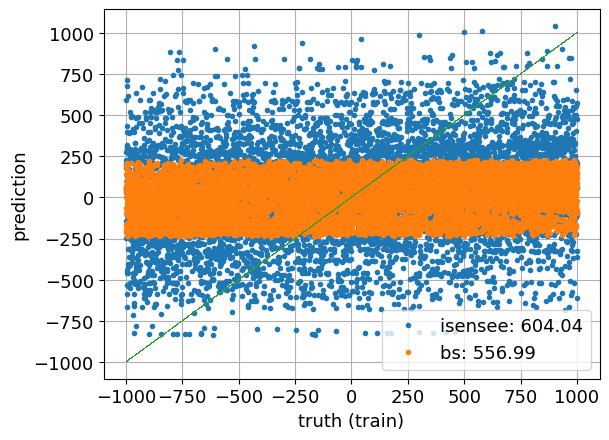

In [30]:
# check the accuracy of some training data
ipreds = isensee_model.predict(X_train, batch_size=batch_size, verbose="auto")[:, 0]
bpreds = bs_model.predict(X_train, batch_size=batch_size, verbose="auto")[:, 0]
truth = y_train

irmse = np.sqrt(((ipreds - truth) ** 2).mean())
brmse = np.sqrt(((bpreds - truth) ** 2).mean())

plt.plot(truth, ipreds, ".", label=f'isensee: {irmse:.2f}')
plt.plot(truth, bpreds, ".", label=f'bs: {brmse:.2f}')
plt.plot(truth, truth, ",")
plt.xlabel("truth (train)")
plt.grid()
plt.ylabel("prediction")
plt.legend()
plt.savefig(f"{plot_dir}/{basename}_train.png")
plt.show()

32/32 [==============================] - 3s 10ms/step


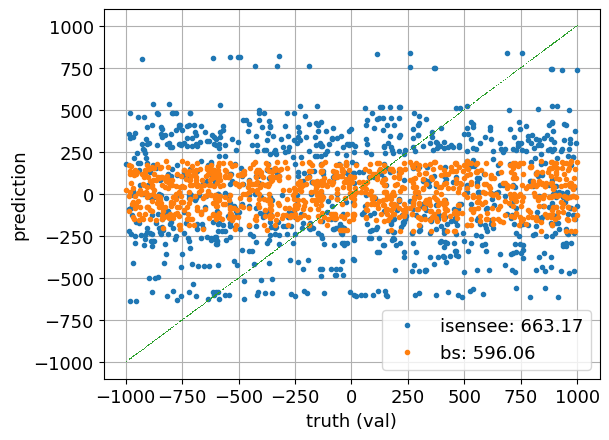

In [31]:
# check the accuracy of some training data
ipreds = isensee_model.predict(X_val, batch_size=batch_size, verbose="auto")[:, 0]
bpreds = bs_model.predict(X_val, batch_size=batch_size, verbose="auto")[:, 0]
truth = y_val

irmse = np.sqrt(((ipreds - truth) ** 2).mean())
brmse = np.sqrt(((bpreds - truth) ** 2).mean())

plt.plot(truth, ipreds, ".", label=f'isensee: {irmse:.2f}')
plt.plot(truth, bpreds, ".", label=f'bs: {brmse:.2f}')
plt.plot(truth, truth, ",")
plt.xlabel("truth (val)")
plt.grid()
plt.ylabel("prediction")
plt.legend()
plt.savefig(f"{plot_dir}/{basename}_val.png")
plt.show()

Model has not seen the test data, so this is the best view of preformance.

32/32 [==============================] - 0s 10ms/step


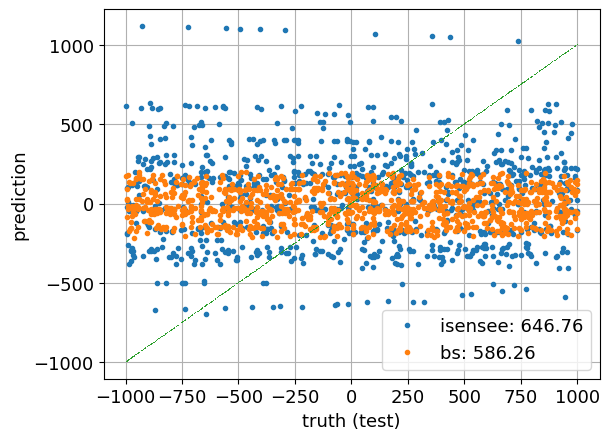

In [32]:
# check the accuracy of some training data
ipreds = isensee_model.predict(X_test, batch_size=batch_size, verbose="auto")[:, 0]
bpreds = bs_model.predict(X_test, batch_size=batch_size, verbose="auto")[:, 0]
truth = y_test

irmse = np.sqrt(((ipreds - truth) ** 2).mean())
brmse = np.sqrt(((bpreds - truth) ** 2).mean())

plt.plot(truth, ipreds, ".", label=f'isensee: {irmse:.2f}')
plt.plot(truth, bpreds, ".", label=f'bs: {brmse:.2f}')
plt.plot(truth, truth, ",")
plt.xlabel("truth (test)")
plt.grid()
plt.ylabel("prediction")
plt.legend()

plt.savefig(f"{plot_dir}/{basename}_test.png")
plt.show()